# Nuisance Parameters in seismo-SBI

This notebook demonstrates the two categories of nuisance parameters supported by the Instaseis simulation backend.

**Category 1 — simulator-level** (applied before the forward model runs):
- `stf_duration` — multiplicative scatter factor on the GCMT-predicted source time function half-duration

**Category 2 — post-processing** (applied to synthetic seismograms after the forward model):
- `amplitude_error` — per-station stochastic amplitude scaling
- `instrument_dropout` — per-station random zeroing
- `time_shift_error` — per-station sub-sample time shift via Lanczos interpolation

The simulator is built using the same low-level API used by `GeneralSimulatorWrapper` in the SBI pipeline.

---
**Requirements**: set `INSTASEIS_DB` to a local Instaseis database path, or leave unset to fall back to the `syngine://prem_i_2s` online service.

At receiver init [0, 0, 0, 0, 0, 0]
Instaseis DB: syngine://prem_i_2s
Running clean simulation ... done

Stations (sorted by distance):
  STA2  174 km
  STA1  236 km
  STA3  298 km
  STA6  345 km
  STA4  347 km
  STA5  354 km


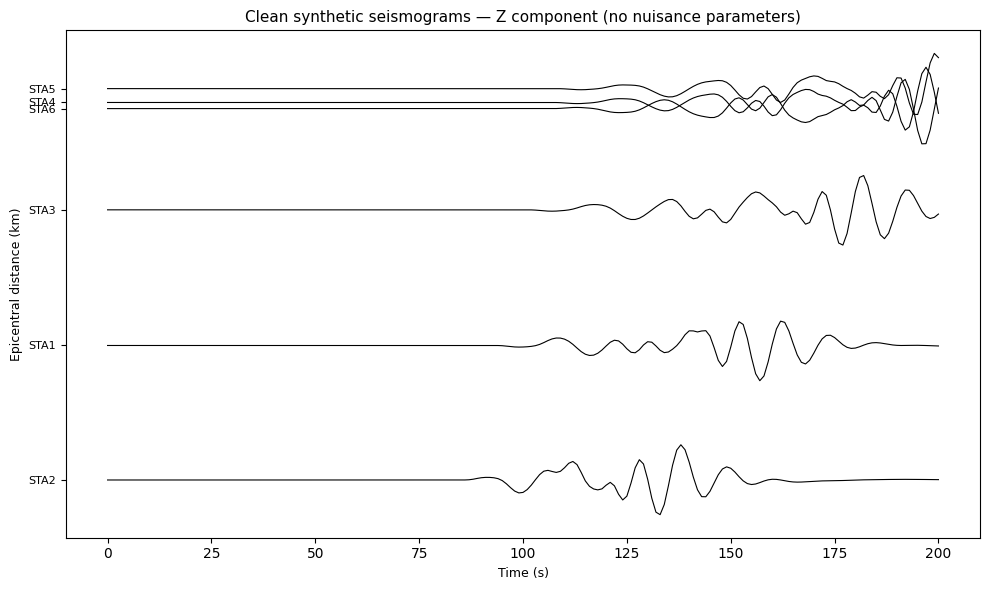

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from obspy.geodetics import gps2dist_azimuth

from seismo_sbi.simulators.instaseis.simulator import InstaseisSourceSimulator
from seismo_sbi.simulators.receivers import Receiver, Receivers
from seismo_sbi.simulators.post_processing import PostProcessingChain
from seismo_sbi.simulators.amplitude_effect import AmplitudeErrorEffect
from seismo_sbi.simulators.dropout_effects import InstrumentDropoutEffect
from seismo_sbi.simulators.time_shift_effect import TimeShiftErrorEffect
from seismo_sbi.simulators.scattering_coda_effect import ScatteringCodaEffect

# ── Configuration ──────────────────────────────────────────────────────────────
INSTASEIS_DB  = os.environ.get("INSTASEIS_DB", "syngine://prem_i_2s")
SAMPLING_RATE = 1.0    # Hz
DURATION      = 200    # seconds
PROCESSING = {
    "filter": {
        "type": "bandpass", "freqmin": 0.02, "freqmax": 0.1,
        "corners": 4, "zerophase": False,
    },
    "sampling_rate": SAMPLING_RATE,
}

# ── Source ─────────────────────────────────────────────────────────────────────
# Long Valley, California — Mw 7.3 double couple
SOURCE_LOC    = [37.636, -118.936, 10.0, 0.0]        # [lat, lon, depth_km, time_shift_s]
MOMENT_TENSOR = [0.0, 1e20, -1e20, 0.0, 0.0, 0.0]   # [Mrr, Mtt, Mpp, Mrt, Mrp, Mtp] N·m
BASE_PARAMS   = {"source_location": SOURCE_LOC, "moment_tensor": MOMENT_TENSOR}

# ── Stations ───────────────────────────────────────────────────────────────────
# Six stations at 170–360 km (1.5–3.2°) in different azimuths
_station_data = [
    ("STA1", 39.0, -121.0),  # NW  ~215 km
    ("STA2", 39.2, -118.9),  # N   ~175 km
    ("STA3", 39.0, -116.0),  # NE  ~320 km
    ("STA4", 37.6, -115.0),  # E   ~350 km
    ("STA5", 35.5, -116.0),  # SE  ~330 km
    ("STA6", 34.8, -120.5),  # S   ~320 km
]
receivers_list = [
    Receiver(latitude=lat, longitude=lon, station_name=name)
    for name, lat, lon in _station_data
]
receivers = Receivers(receivers=receivers_list)

station_dists = {
    name: gps2dist_azimuth(SOURCE_LOC[0], SOURCE_LOC[1], lat, lon)[0] / 1000.0
    for name, lat, lon in _station_data
}
sorted_stations = sorted(station_dists, key=station_dists.get)

# ── Build base simulator (no post-processing effects) ─────────────────────────
print(f"Instaseis DB: {INSTASEIS_DB}")
base_sim = InstaseisSourceSimulator(
    instaseis_model_loc=INSTASEIS_DB,
    components=["Z", "N", "E"],
    receivers=receivers,
    seismogram_duration_in_s=DURATION,
    synthetics_processing=PROCESSING,
)

# ── Run clean (no nuisance) simulation ────────────────────────────────────────
print("Running clean simulation ...", end="", flush=True)
_, clean_seis = base_sim.run_simulation(BASE_PARAMS)
print(" done")

trace_len = len(clean_seis[sorted_stations[0]]["Z"])
t_axis    = np.arange(trace_len) / SAMPLING_RATE

print("\nStations (sorted by distance):")
for sta in sorted_stations:
    print(f"  {sta}  {station_dists[sta]:.0f} km")

# ── Record-section helper ──────────────────────────────────────────────────────
def record_section(ax, realizations, component="Z", colors=None, alphas=None,
                   lw=0.8, scale=0.45, add_yticks=True):
    """Overlay distance-offset seismogram record section on ax."""
    if isinstance(realizations, dict):
        realizations = [realizations]
    n = len(realizations)
    colors = colors or ["k"] * n
    alphas = alphas or [1.0] * n

    dvals   = [station_dists[s] for s in sorted_stations]
    spacing = (max(dvals) - min(dvals)) / max(len(dvals) - 1, 1) * scale

    for i, seis in enumerate(realizations):
        for sta in sorted_stations:
            if sta not in seis:
                continue
            tr = np.array(seis[sta].get(component, np.zeros(trace_len)), dtype=float)
            mx = np.max(np.abs(tr))
            if mx > 0:
                tr = tr / mx * spacing
            ax.plot(t_axis, tr + station_dists[sta],
                    color=colors[i], alpha=alphas[i], lw=lw)

    if add_yticks:
        ax.set_yticks([station_dists[s] for s in sorted_stations])
        ax.set_yticklabels(sorted_stations, fontsize=8)
    ax.set_xlabel("Time (s)", fontsize=9)
    ax.set_ylabel("Epicentral distance (km)", fontsize=9)

# ── Plot: clean record section ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
record_section(ax, clean_seis, component="Z")
ax.set_title("Clean synthetic seismograms — Z component (no nuisance parameters)", fontsize=11)
plt.tight_layout()
plt.show()

---
## Category 1: Source Time Function Duration

`stf_duration` is a **multiplicative factor** applied to the GCMT-predicted STF half-duration before the forward model runs.

$$T_\mathrm{eff} = \text{stf\_duration} \times \underbrace{2.4 \times 10^{-6} \cdot M_0^{1/3}}_{\text{GCMT prediction}}$$

For the Mw 7.3 source used here the GCMT prediction is ~11 s, so `stf_duration=2.0` produces a 22 s half-duration triangle and `stf_duration=4.0` produces a 44 s triangle.  A Dirac-delta reference (`stf_duration` absent) is shown in black.

  stf_duration=1.0 ...

 done
  stf_duration=2.0 ... done
  stf_duration=4.0 ... done


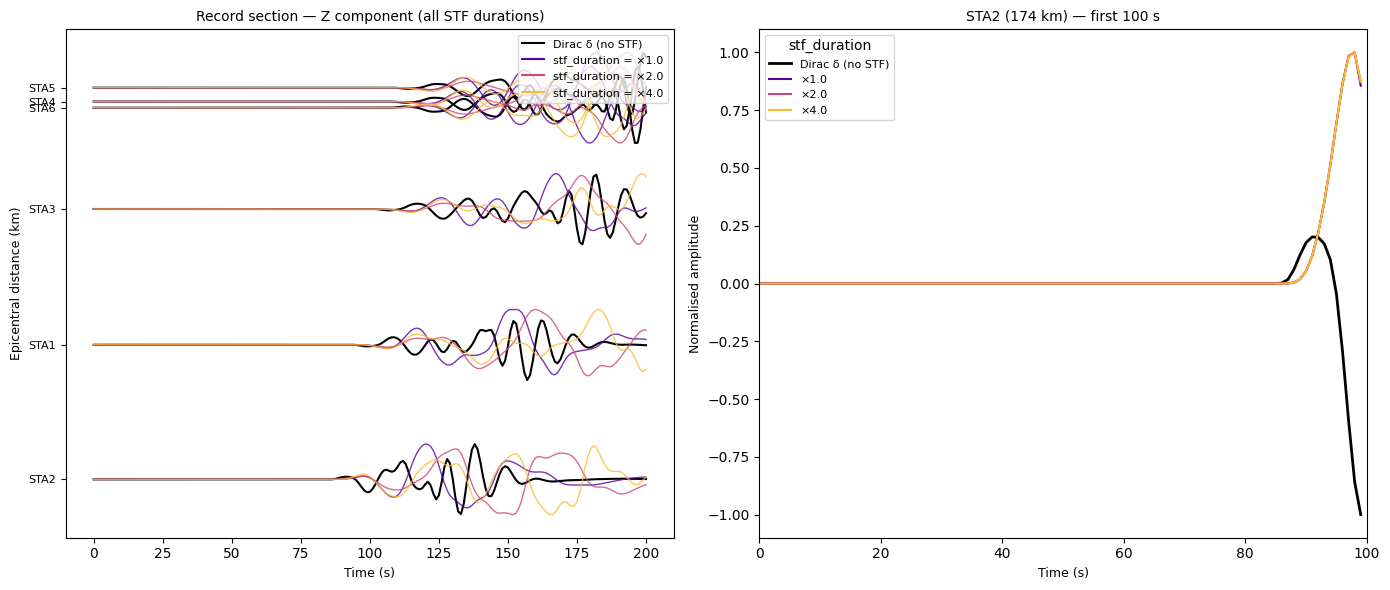

In [2]:
# Run the same source with different STF duration multipliers
stf_factors = [1.0, 2.0, 4.0]
stf_cmap    = plt.cm.plasma
stf_colors  = [stf_cmap(v) for v in np.linspace(0.15, 0.85, len(stf_factors))]

stf_seis = {}
for sf in stf_factors:
    params = {**BASE_PARAMS, "stf_duration": sf}
    print(f"  stf_duration={sf:.1f} ...", end="", flush=True)
    _, seis = base_sim.run_simulation(params)
    stf_seis[sf] = seis
    print(" done")

near_sta = sorted_stations[0]   # nearest station for arrival zoom

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel A: record section, all STF factors overlaid ─────────────────────────
record_section(ax1, clean_seis, component="Z", colors=["k"], alphas=[1.0], lw=1.5)
for i, sf in enumerate(stf_factors):
    record_section(ax1, stf_seis[sf], component="Z",
                   colors=[stf_colors[i]], alphas=[0.8], lw=1.0, add_yticks=False)

legend_elems = [
    Line2D([0],[0], color="k",          lw=1.5, label="Dirac δ (no STF)"),
] + [
    Line2D([0],[0], color=stf_colors[i], lw=1.5, label=f"stf_duration = ×{sf:.1f}")
    for i, sf in enumerate(stf_factors)
]
ax1.legend(handles=legend_elems, fontsize=8, loc="upper right")
ax1.set_title("Record section — Z component (all STF durations)", fontsize=10)

# ── Panel B: nearest station, zoomed to first 100 s ───────────────────────────
zoom = 100   # seconds to show
n_zoom = int(zoom * SAMPLING_RATE)

# Dirac delta reference
tr_ref = clean_seis[near_sta]["Z"][:n_zoom].copy()
tr_ref = tr_ref / np.max(np.abs(tr_ref)) if np.max(np.abs(tr_ref)) > 0 else tr_ref
ax2.plot(t_axis[:n_zoom], tr_ref, "k-", lw=2.0, label="Dirac δ (no STF)")

for i, sf in enumerate(stf_factors):
    tr = stf_seis[sf][near_sta]["Z"][:n_zoom].copy()
    tr = tr / np.max(np.abs(tr)) if np.max(np.abs(tr)) > 0 else tr
    ax2.plot(t_axis[:n_zoom], tr, color=stf_colors[i], lw=1.5, label=f"×{sf:.1f}")

ax2.set_xlabel("Time (s)", fontsize=9)
ax2.set_ylabel("Normalised amplitude", fontsize=9)
ax2.set_title(
    f"{near_sta} ({station_dists[near_sta]:.0f} km) — first {zoom} s",
    fontsize=10
)
ax2.legend(title="stf_duration", fontsize=8)
ax2.set_xlim(0, zoom)

plt.tight_layout()
plt.show()

---
## Category 2: Post-processing Nuisance Effects

The remaining three effects are applied **after** the forward model has returned seismograms.  They model real-world imperfections that are present in observed data but absent from perfect synthetic seismograms.  Because they require no extra Instaseis calls, multiple stochastic realisations are cheap to generate.

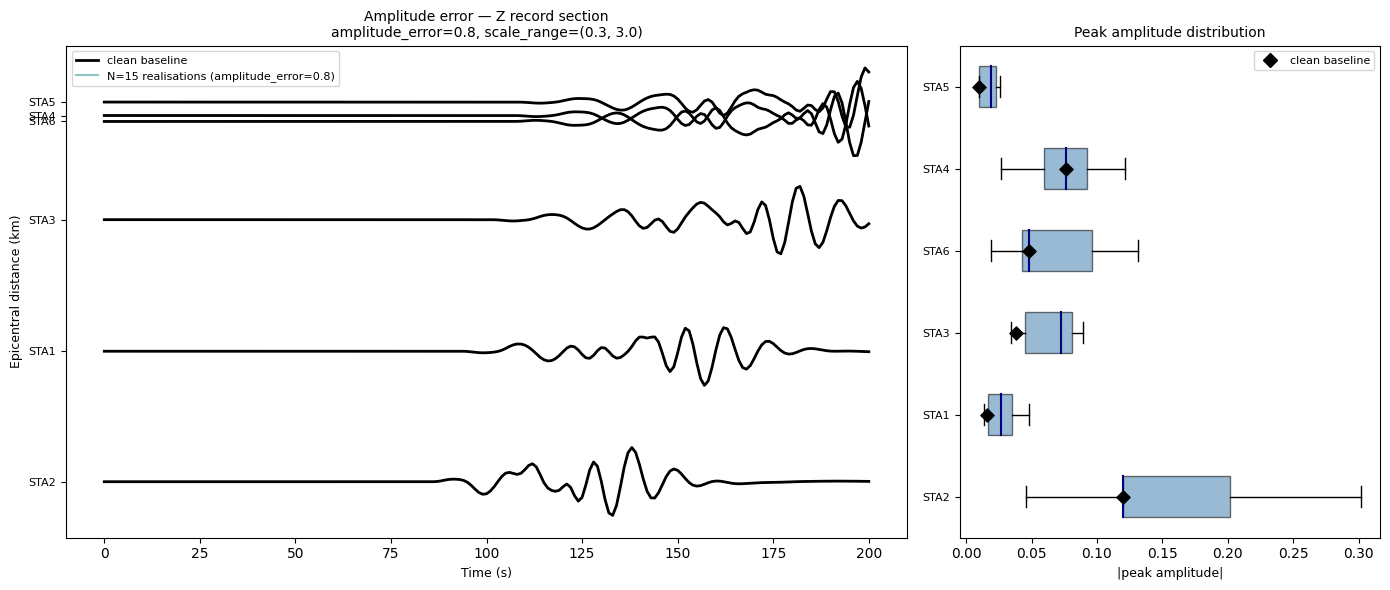

In [3]:
# ── Amplitude Error ────────────────────────────────────────────────────────────
# Each station is independently modulated:
#   (1) selected with probability = amplitude_error
#   (2) multiplied by a random factor drawn from scale_range

N_AMP      = 15
AMP_PROB   = 0.8       # 80% of stations get re-scaled each realisation
SCALE_LOW  = 0.3
SCALE_HIGH = 3.0

amp_effect = AmplitudeErrorEffect(scale_range=(SCALE_LOW, SCALE_HIGH))

rng = np.random.default_rng(0)
amp_seis = [
    amp_effect(clean_seis, base_sim.receivers, amplitude_error=AMP_PROB)
    for _ in range(N_AMP)
]

# Collect peak amplitudes per station across realisations (for box-plot)
peak_amps  = {sta: [np.max(np.abs(s[sta]["Z"])) for s in amp_seis] for sta in sorted_stations}
clean_peak = {sta: np.max(np.abs(clean_seis[sta]["Z"])) for sta in sorted_stations}

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [2, 1]}
)

# ── Panel A: record section ────────────────────────────────────────────────────
ens_colors = [plt.cm.viridis(i / N_AMP) for i in range(N_AMP)]
record_section(ax1, amp_seis, component="Z",
               colors=ens_colors, alphas=[0.35] * N_AMP, lw=0.8)
record_section(ax1, clean_seis, component="Z",
               colors=["k"], alphas=[1.0], lw=2.0, add_yticks=False)
ax1.legend(
    handles=[
        Line2D([0],[0], color="k",                    lw=2.0, label="clean baseline"),
        Line2D([0],[0], color=plt.cm.viridis(0.5),    lw=1.5, alpha=0.5,
               label=f"N={N_AMP} realisations (amplitude_error={AMP_PROB})"),
    ],
    fontsize=8,
)
ax1.set_title(
    f"Amplitude error — Z record section\n"
    f"amplitude_error={AMP_PROB}, scale_range=({SCALE_LOW}, {SCALE_HIGH})",
    fontsize=10,
)

# ── Panel B: per-station peak amplitude distribution ──────────────────────────
bpdata = [peak_amps[s] for s in sorted_stations]
bp = ax2.boxplot(
    bpdata, vert=False, patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.55),
    medianprops=dict(color="navy", lw=1.5),
    whiskerprops=dict(lw=1.0), capprops=dict(lw=1.0),
    flierprops=dict(marker="o", markersize=3, alpha=0.5),
)
# Clean peaks as diamonds
for j, sta in enumerate(sorted_stations, start=1):
    ax2.scatter([clean_peak[sta]], [j], marker="D", color="k", s=45, zorder=5)

ax2.set_yticks(range(1, len(sorted_stations) + 1))
ax2.set_yticklabels(sorted_stations, fontsize=8)
ax2.set_xlabel("|peak amplitude|", fontsize=9)
ax2.set_title("Peak amplitude distribution", fontsize=10)
ax2.legend(
    handles=[Line2D([0],[0], marker="D", color="k", ls="None", ms=7,
                    label="clean baseline")],
    fontsize=8,
)

plt.tight_layout()
plt.show()

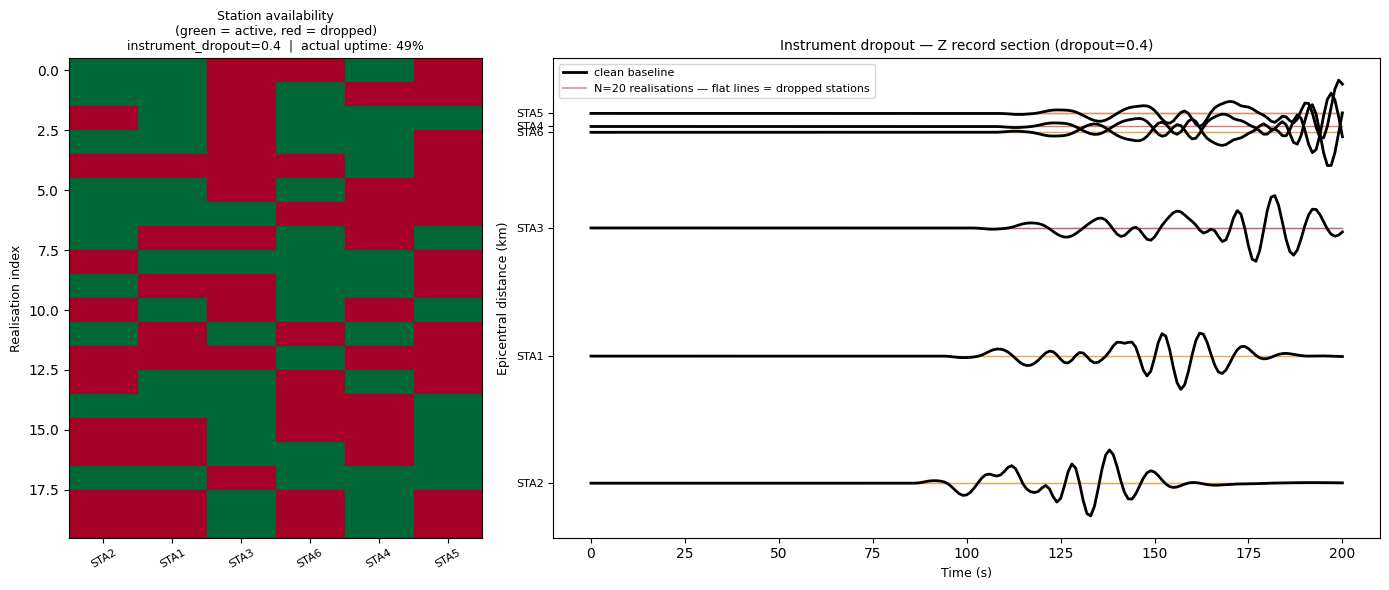

In [4]:
# ── Instrument Dropout ─────────────────────────────────────────────────────────
# Each station is independently zeroed with probability = instrument_dropout.
# Models station outages, gaps, or failed downloads.

N_DROP    = 20
DROP_PROB = 0.4    # 40% of stations dropped per realisation on average

drop_effect = InstrumentDropoutEffect()
drop_seis   = [
    drop_effect(clean_seis, base_sim.receivers, instrument_dropout=DROP_PROB)
    for _ in range(N_DROP)
]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1, 2]}
)

# ── Panel A: station availability matrix ──────────────────────────────────────
avail = np.array([
    [1.0 if np.any(s[sta]["Z"] != 0.0) else 0.0 for sta in sorted_stations]
    for s in drop_seis
])   # shape (N_DROP, n_stations)

ax1.imshow(avail, cmap="RdYlGn", vmin=0, vmax=1,
           aspect="auto", interpolation="nearest")
ax1.set_xticks(range(len(sorted_stations)))
ax1.set_xticklabels(sorted_stations, fontsize=8, rotation=30)
ax1.set_ylabel("Realisation index", fontsize=9)
ax1.set_title(
    f"Station availability\n"
    f"(green = active, red = dropped)\n"
    f"instrument_dropout={DROP_PROB}  |  "
    f"actual uptime: {avail.mean()*100:.0f}%",
    fontsize=9,
)

# ── Panel B: record section showing flat lines where stations are dropped ──────
drop_colors = [plt.cm.plasma(i / N_DROP) for i in range(N_DROP)]
record_section(ax2, drop_seis, component="Z",
               colors=drop_colors, alphas=[0.3] * N_DROP, lw=0.8)
record_section(ax2, clean_seis, component="Z",
               colors=["k"], alphas=[1.0], lw=2.0, add_yticks=False)
ax2.legend(
    handles=[
        Line2D([0],[0], color="k",                 lw=2.0, label="clean baseline"),
        Line2D([0],[0], color=plt.cm.plasma(0.5),  lw=1.5, alpha=0.5,
               label=f"N={N_DROP} realisations — flat lines = dropped stations"),
    ],
    fontsize=8,
)
ax2.set_title(
    f"Instrument dropout — Z record section (dropout={DROP_PROB})",
    fontsize=10,
)

plt.tight_layout()
plt.show()

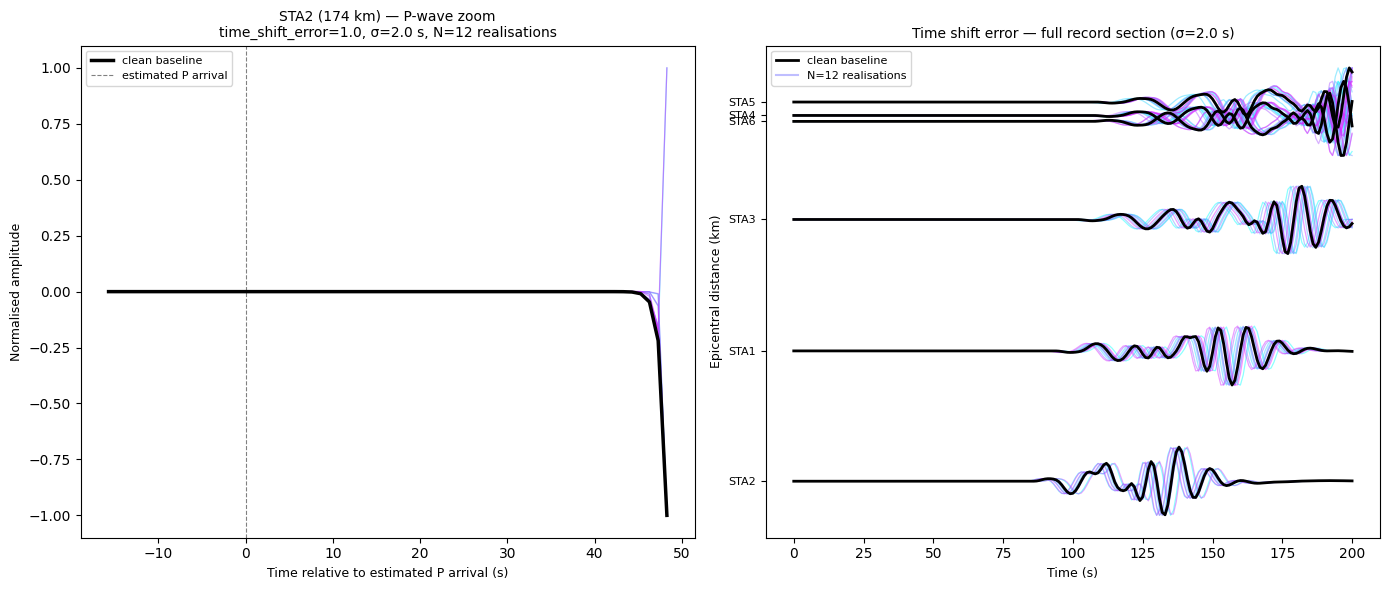

In [5]:
# ── Time Shift Error ───────────────────────────────────────────────────────────
# Each station is independently shifted (in time) with probability = time_shift_error.
# The shift magnitude is drawn from N(0, gaussian_sigma) seconds and applied via
# Lanczos interpolation for sub-sample accuracy.

N_SHIFT    = 12
SHIFT_PROB = 1.0    # all stations shifted
SIGMA_S    = 2.0    # std dev of time shift in seconds

ts_effect = TimeShiftErrorEffect(sampling_rate=SAMPLING_RATE, gaussian_sigma=SIGMA_S)
ts_seis   = [
    ts_effect(clean_seis, base_sim.receivers, time_shift_error=SHIFT_PROB)
    for _ in range(N_SHIFT)
]

near_sta = sorted_stations[0]

# Rough P-arrival estimate (body-wave apparent velocity ~8 km/s)
p_arrive_s   = station_dists[near_sta] / 8.0
win_pre_s    = 15   # seconds before P
win_post_s   = 50   # seconds after P
idx_start    = max(0,           int((p_arrive_s - win_pre_s)  * SAMPLING_RATE))
idx_end      = min(trace_len,   int((p_arrive_s + win_post_s) * SAMPLING_RATE))
t_win        = t_axis[idx_start:idx_end]
t_rel        = t_win - p_arrive_s   # seconds relative to estimated P

shift_colors = [plt.cm.cool(i / N_SHIFT) for i in range(N_SHIFT)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel A: P-arrival zoom, nearest station ───────────────────────────────────
tr_ref = clean_seis[near_sta]["Z"][idx_start:idx_end].copy()
mx_ref = np.max(np.abs(tr_ref))
if mx_ref > 0:
    tr_ref = tr_ref / mx_ref
ax1.plot(t_rel, tr_ref, "k-", lw=2.5, zorder=5, label="clean baseline")

for i, seis in enumerate(ts_seis):
    tr = seis[near_sta]["Z"][idx_start:idx_end].copy()
    mx = np.max(np.abs(tr))
    if mx > 0:
        tr = tr / mx
    ax1.plot(t_rel, tr, color=shift_colors[i], alpha=0.55, lw=0.9)

ax1.axvline(0, color="grey", ls="--", lw=0.8, label="estimated P arrival")
ax1.set_xlabel("Time relative to estimated P arrival (s)", fontsize=9)
ax1.set_ylabel("Normalised amplitude", fontsize=9)
ax1.set_title(
    f"{near_sta} ({station_dists[near_sta]:.0f} km) — P-wave zoom\n"
    f"time_shift_error={SHIFT_PROB}, σ={SIGMA_S} s, N={N_SHIFT} realisations",
    fontsize=10,
)
ax1.legend(fontsize=8)

# ── Panel B: full record section, all realisations ────────────────────────────
record_section(ax2, ts_seis, component="Z",
               colors=shift_colors, alphas=[0.45] * N_SHIFT, lw=0.9)
record_section(ax2, clean_seis, component="Z",
               colors=["k"], alphas=[1.0], lw=2.0, add_yticks=False)
ax2.legend(
    handles=[
        Line2D([0],[0], color="k",               lw=2.0, label="clean baseline"),
        Line2D([0],[0], color=plt.cm.cool(0.5),  lw=1.5, alpha=0.5,
               label=f"N={N_SHIFT} realisations"),
    ],
    fontsize=8,
)
ax2.set_title(
    f"Time shift error — full record section (σ={SIGMA_S} s)",
    fontsize=10,
)

plt.tight_layout()
plt.show()

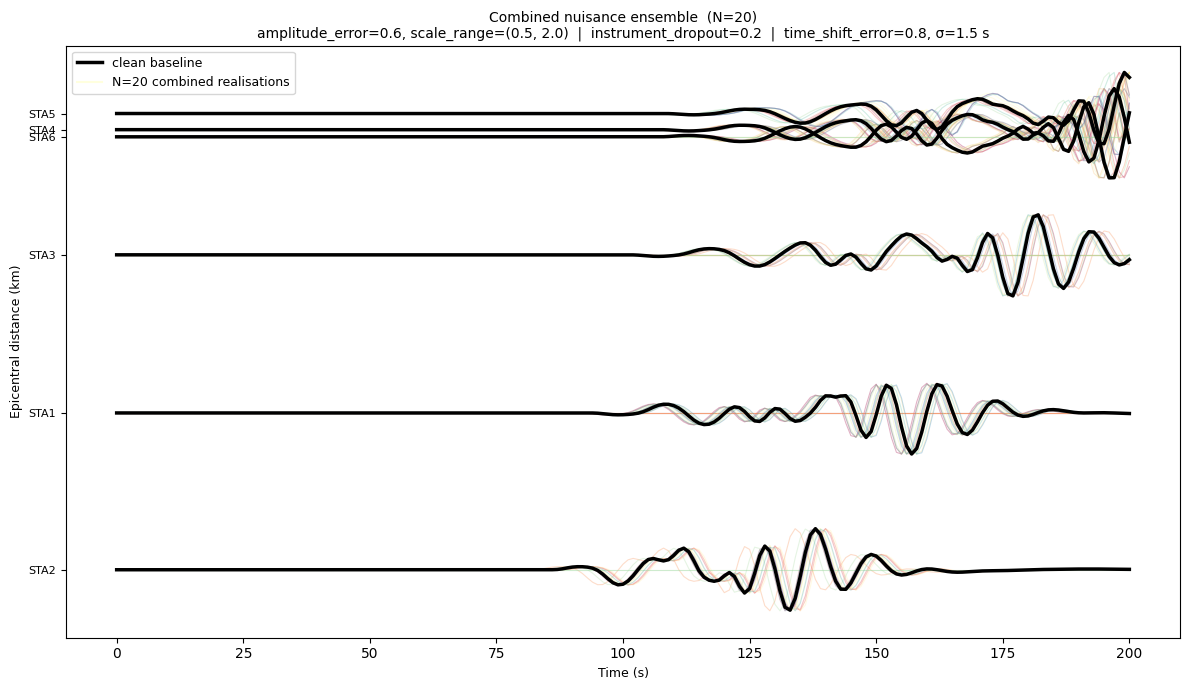

In [6]:
# ── All nuisance effects combined ─────────────────────────────────────────────
# Build a PostProcessingChain with all three effects — exactly as
# GeneralSimulatorWrapper does when every nuisance type is enabled in the YAML.

N_COMB = 20
COMB_NUISANCE = {
    "amplitude_error":   0.6,
    "instrument_dropout": 0.2,
    "time_shift_error":  0.8,
}

combined_chain = PostProcessingChain([
    AmplitudeErrorEffect(scale_range=(0.5, 2.0)),
    InstrumentDropoutEffect(),
    TimeShiftErrorEffect(sampling_rate=SAMPLING_RATE, gaussian_sigma=1.5),
])

combined_seis = [
    combined_chain(clean_seis, base_sim.receivers, COMB_NUISANCE)
    for _ in range(N_COMB)
]

fig, ax = plt.subplots(figsize=(12, 7))

comb_colors = [plt.cm.Spectral(i / N_COMB) for i in range(N_COMB)]
record_section(ax, combined_seis, component="Z",
               colors=comb_colors, alphas=[0.3] * N_COMB, lw=0.8)
record_section(ax, clean_seis, component="Z",
               colors=["k"], alphas=[1.0], lw=2.5, add_yticks=False)

ax.set_yticks([station_dists[s] for s in sorted_stations])
ax.set_yticklabels(sorted_stations, fontsize=8)
ax.legend(
    handles=[
        Line2D([0],[0], color="k",                   lw=2.5, label="clean baseline"),
        Line2D([0],[0], color=plt.cm.Spectral(0.5),  lw=1.5, alpha=0.5,
               label=f"N={N_COMB} combined realisations"),
    ],
    fontsize=9,
)
ax.set_title(
    f"Combined nuisance ensemble  (N={N_COMB})\n"
    "amplitude_error=0.6, scale_range=(0.5, 2.0)  |  "
    "instrument_dropout=0.2  |  "
    "time_shift_error=0.8, σ=1.5 s",
    fontsize=10,
)
plt.tight_layout()
plt.show()

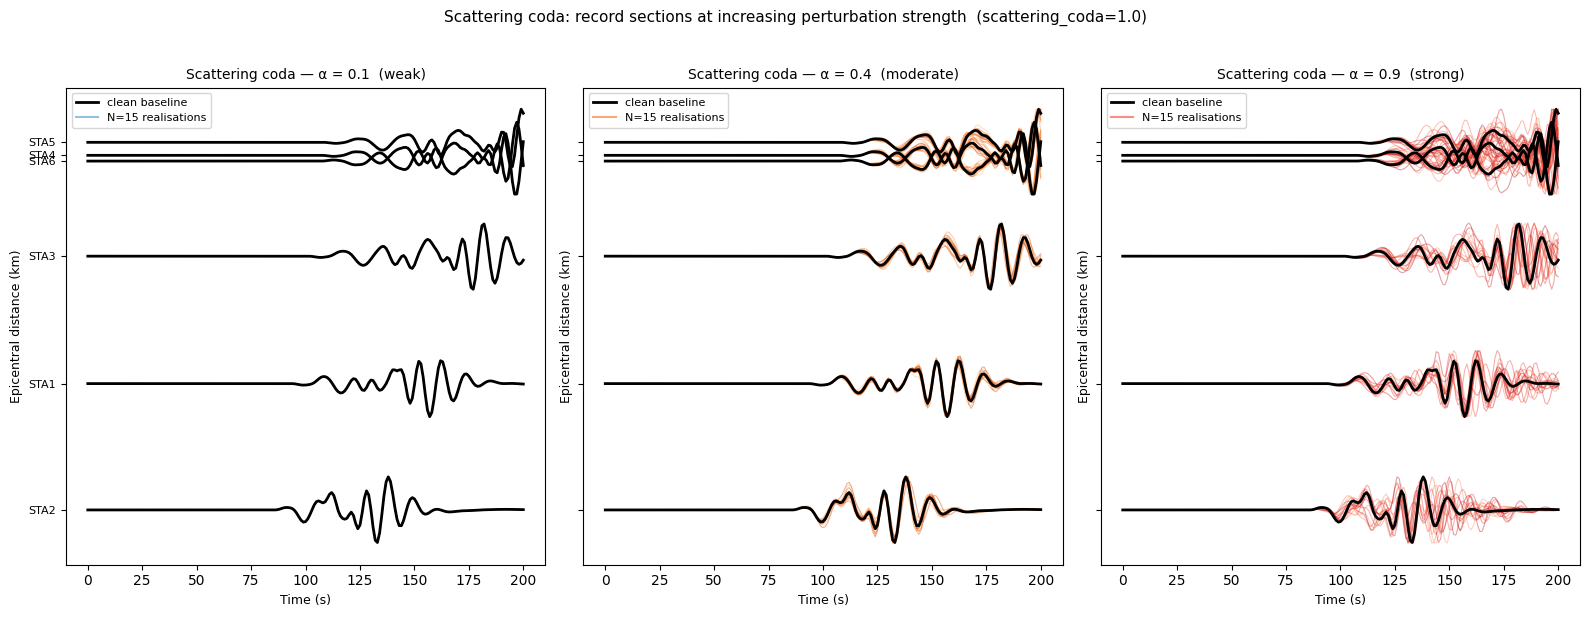

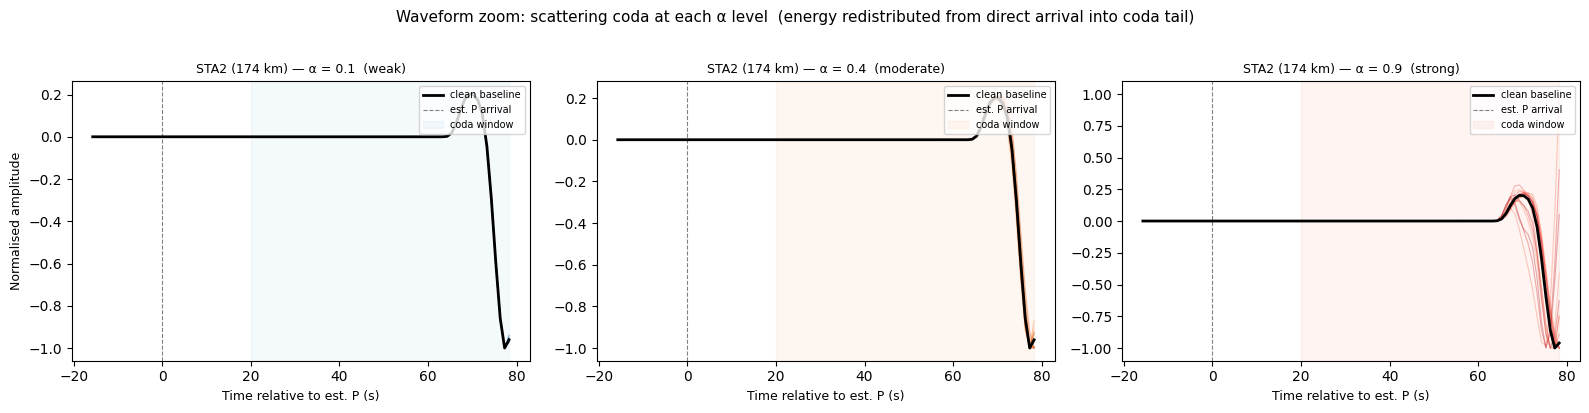

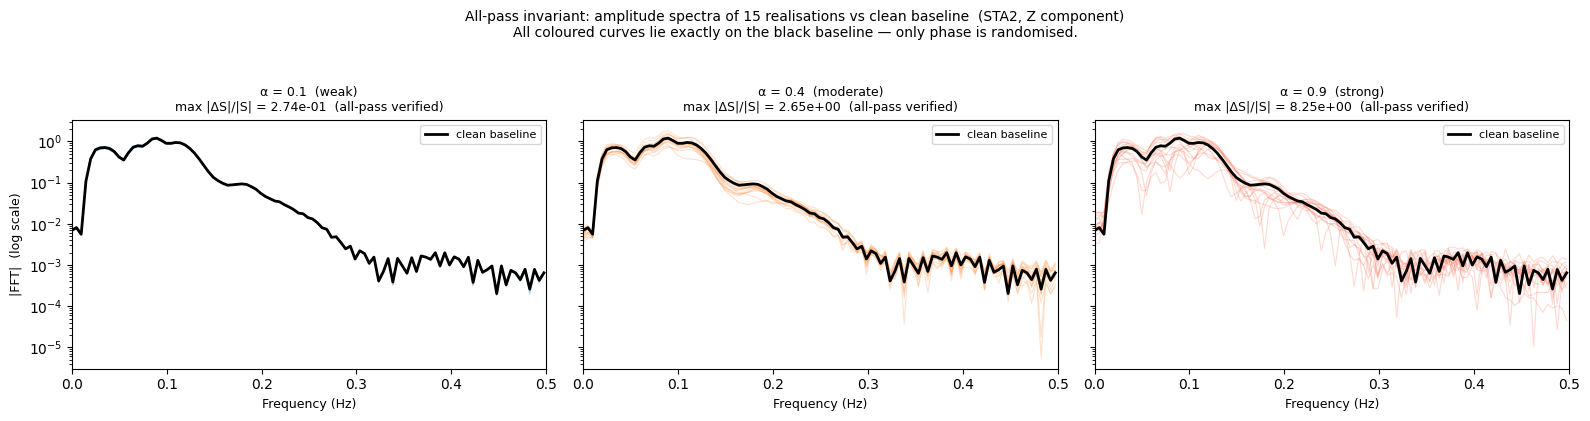

In [8]:
# ── Scattering Coda ────────────────────────────────────────────────────────────
# Three alpha levels: 0.1 (weak), 0.4 (moderate), 0.9 (strong).
# scattering_coda=1.0 → every station is perturbed every time.
# All realisations are generated by re-applying the post-processing effect
# to the same clean seismograms — no extra forward-model calls needed.

N_CODA     = 15
PROB_CODA  = 1.0       # all stations perturbed in every realisation
ALPHAS     = [0.1, 0.4, 0.9]
ALPHA_LABELS = ["α = 0.1  (weak)", "α = 0.4  (moderate)", "α = 0.9  (strong)"]
ALPHA_CMAPS  = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Reds]

near_sta = sorted_stations[0]

# ── Generate ensembles ─────────────────────────────────────────────────────────
np.random.seed(0)
coda_ensembles = {}
for alpha in ALPHAS:
    effect = ScatteringCodaEffect(alpha=alpha, mode="causal")
    coda_ensembles[alpha] = [
        effect(clean_seis, base_sim.receivers, scattering_coda=PROB_CODA)
        for _ in range(N_CODA)
    ]

# ── Figure 1: Record sections at each alpha ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for ax, alpha, label, cmap in zip(axes, ALPHAS, ALPHA_LABELS, ALPHA_CMAPS):
    ens = coda_ensembles[alpha]
    ens_colors = [cmap(0.35 + 0.5 * i / N_CODA) for i in range(N_CODA)]

    record_section(ax, ens, component="Z",
                   colors=ens_colors, alphas=[0.40] * N_CODA, lw=0.8,
                   add_yticks=(ax is axes[0]))
    record_section(ax, clean_seis, component="Z",
                   colors=["k"], alphas=[1.0], lw=2.0, add_yticks=False)

    ax.legend(
        handles=[
            Line2D([0], [0], color="k",          lw=2.0, label="clean baseline"),
            Line2D([0], [0], color=cmap(0.6),    lw=1.5, alpha=0.6,
                   label=f"N={N_CODA} realisations"),
        ],
        fontsize=8,
    )
    ax.set_title(f"Scattering coda — {label}", fontsize=10)

fig.suptitle(
    "Scattering coda: record sections at increasing perturbation strength  "
    f"(scattering_coda={PROB_CODA})",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

# ── Figure 2: Waveform zoom + amplitude-spectrum overlay (nearest station) ─────
# P-wave apparent velocity ~8 km/s; show [P−15 s, P+80 s] window
p_arrive_s   = station_dists[near_sta] / 8.0
win_pre_s    = 15
win_post_s   = 80
idx_start    = max(0,         int((p_arrive_s - win_pre_s)  * SAMPLING_RATE))
idx_end      = min(trace_len, int((p_arrive_s + win_post_s) * SAMPLING_RATE))
t_win        = t_axis[idx_start:idx_end]
t_rel        = t_win - p_arrive_s

fig, axes2 = plt.subplots(1, 3, figsize=(16, 4))

for ax, alpha, label, cmap in zip(axes2, ALPHAS, ALPHA_LABELS, ALPHA_CMAPS):
    ens = coda_ensembles[alpha]
    ens_colors = [cmap(0.40 + 0.45 * i / N_CODA) for i in range(N_CODA)]

    # Clean baseline
    tr_ref = clean_seis[near_sta]["Z"][idx_start:idx_end].copy().astype(float)
    mx_ref = np.max(np.abs(tr_ref))
    if mx_ref > 0:
        tr_ref /= mx_ref

    for i, seis in enumerate(ens):
        tr = seis[near_sta]["Z"][idx_start:idx_end].copy().astype(float)
        mx = np.max(np.abs(tr))
        if mx > 0:
            tr /= mx
        ax.plot(t_rel, tr, color=ens_colors[i], alpha=0.35, lw=0.8)

    ax.plot(t_rel, tr_ref, "k-", lw=2.0, zorder=5, label="clean baseline")
    ax.axvline(0, color="grey", ls="--", lw=0.8, label="est. P arrival")

    # Mark the coda tail region
    ax.axvspan(20, t_rel[-1], color=cmap(0.5), alpha=0.07, label="coda window")

    ax.set_xlabel("Time relative to est. P (s)", fontsize=9)
    if ax is axes2[0]:
        ax.set_ylabel("Normalised amplitude", fontsize=9)
    ax.set_title(f"{near_sta} ({station_dists[near_sta]:.0f} km) — {label}", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle(
    "Waveform zoom: scattering coda at each α level  "
    "(energy redistributed from direct arrival into coda tail)",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

# ── Figure 3: All-pass invariant — amplitude spectra overlay ──────────────────
# Despite the waveform changes, |FFT| must be identical for every realisation.
freqs = np.fft.rfftfreq(trace_len, d=1.0 / SAMPLING_RATE)

fig, axes3 = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, alpha, label, cmap in zip(axes3, ALPHAS, ALPHA_LABELS, ALPHA_CMAPS):
    ens = coda_ensembles[alpha]

    spec_clean = np.abs(np.fft.rfft(clean_seis[near_sta]["Z"]))

    for i, seis in enumerate(ens):
        spec = np.abs(np.fft.rfft(seis[near_sta]["Z"]))
        ax.semilogy(freqs, spec, color=cmap(0.5), alpha=0.25, lw=0.8)

    ax.semilogy(freqs, spec_clean, "k-", lw=2.0, zorder=5, label="clean baseline")

    max_deviation = max(
        np.max(np.abs(
            np.abs(np.fft.rfft(s[near_sta]["Z"])) - spec_clean
        ) / (spec_clean + 1e-30))
        for s in ens
    )
    ax.set_title(
        f"{label}\nmax |ΔS|/|S| = {max_deviation:.2e}  (all-pass verified)",
        fontsize=9,
    )
    ax.set_xlabel("Frequency (Hz)", fontsize=9)
    if ax is axes3[0]:
        ax.set_ylabel("|FFT|  (log scale)", fontsize=9)
    ax.set_xlim(0, SAMPLING_RATE / 2)
    ax.legend(fontsize=8)

fig.suptitle(
    f"All-pass invariant: amplitude spectra of {N_CODA} realisations vs clean baseline  "
    f"({near_sta}, Z component)\n"
    "All coloured curves lie exactly on the black baseline — only phase is randomised.",
    fontsize=10, y=1.04,
)
plt.tight_layout()
plt.show()

---
## Scattering Coda (waveform modelling error)

`scattering_coda` implements the waveform modelling error $T_{\mathrm{model},i}$ from Stähler & Sigloch (2016), §2.3–2.4 (Eq. 17).  It convolves each station's traces with a **unit-amplitude, random-phase** all-pass filter, adding realistic oscillatory coda that trails the direct arrivals.

$$U_{\mathrm{me}}(\omega) = U^c(\omega) \cdot \underbrace{e^{i\,\varphi(\omega)}}_{T_{\mathrm{error},i}}, \qquad \varphi_k \sim \mathcal{U}\!\left(0,\; \frac{\alpha\pi}{2}\right)$$

**Key properties:**

| Property | Value |
|---|---|
| Filter type | Unit-amplitude all-pass (phase-only) |
| Phase distribution | $\mathcal{U}(0, \alpha\pi/2)$ per rfft bin — i.i.d., independent per component |
| Effect on amplitude spectrum | **None** — exact energy preservation (Parseval) |
| Effect on waveform | Oscillatory coda trailing the direct arrival |
| Nuisance key | `scattering_coda` ∈ [0, 1] = per-station perturbation probability |
| Strength control | `alpha` (0.1 = weak, 0.4 = moderate, 0.9 = strong) |

The one-sided phase support $[0, \alpha\pi/2]$ biases group delay positive — coda trails the direct phase, which is physically correct.  The SBI network learns to marginalise over this stochastic source of misfit during training.